In [1]:
#download cluster annotation from Table S7 in paper
#download cell annotations from GEO
#GSM7950265 	NGN2 post p1 (contains metadata for both NGN2 runs)
#GSM7950267 	NGN2 pre
#GSM7950268 	ASCL1 post
#GSM7950269 	ASCL1 pre

In [2]:
import os
files = os.listdir()
files = [x for x in files if 'GSM' in x]

In [3]:
files

['GSM7950265_NGN2_post_dr_clustered_raw_merged_meta.tsv.gz',
 'GSM7950267_NGN2_pre_dr_clustered_raw_merged_meta.tsv.gz',
 'GSM7950268_ASCL1_post_dr_clustered_raw_merged_meta.tsv.gz',
 'GSM7950269_ASCL1_pre_dr_clustered_raw_merged_meta.tsv.gz']

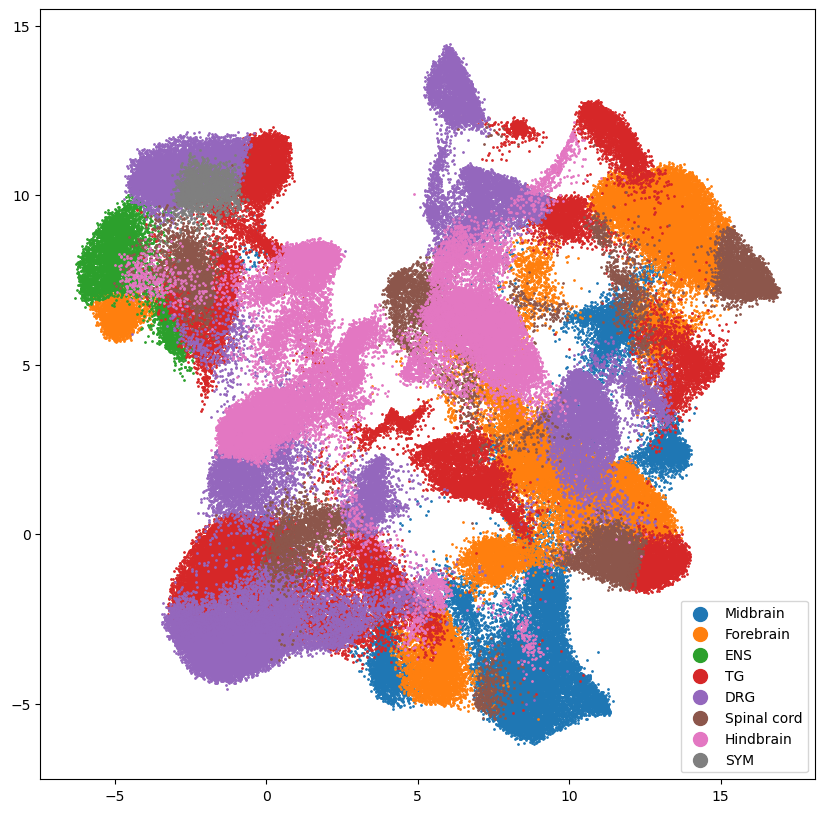

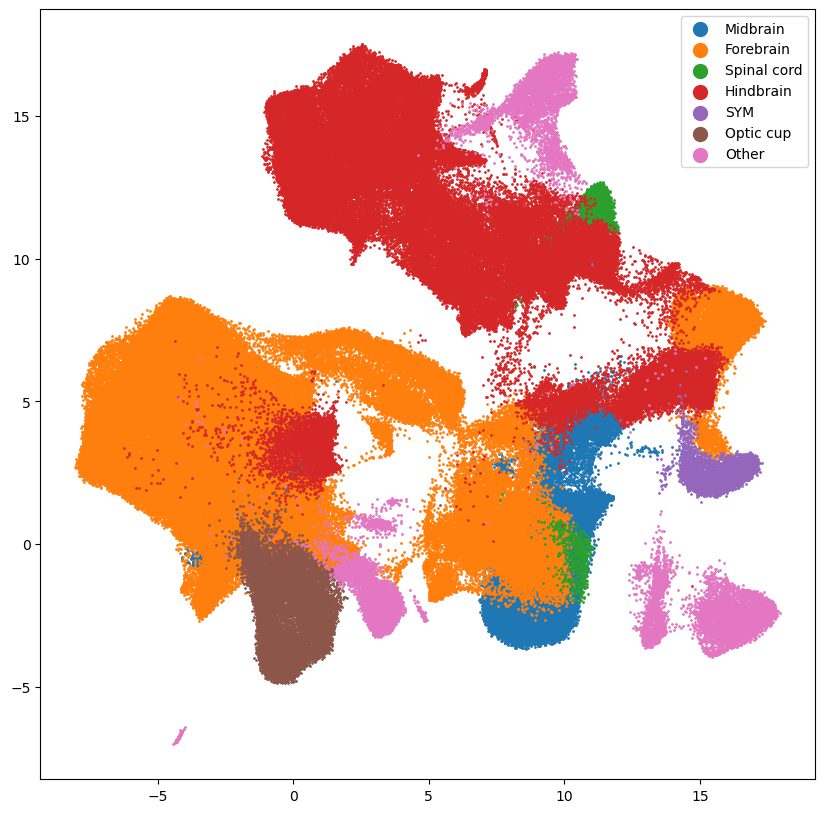

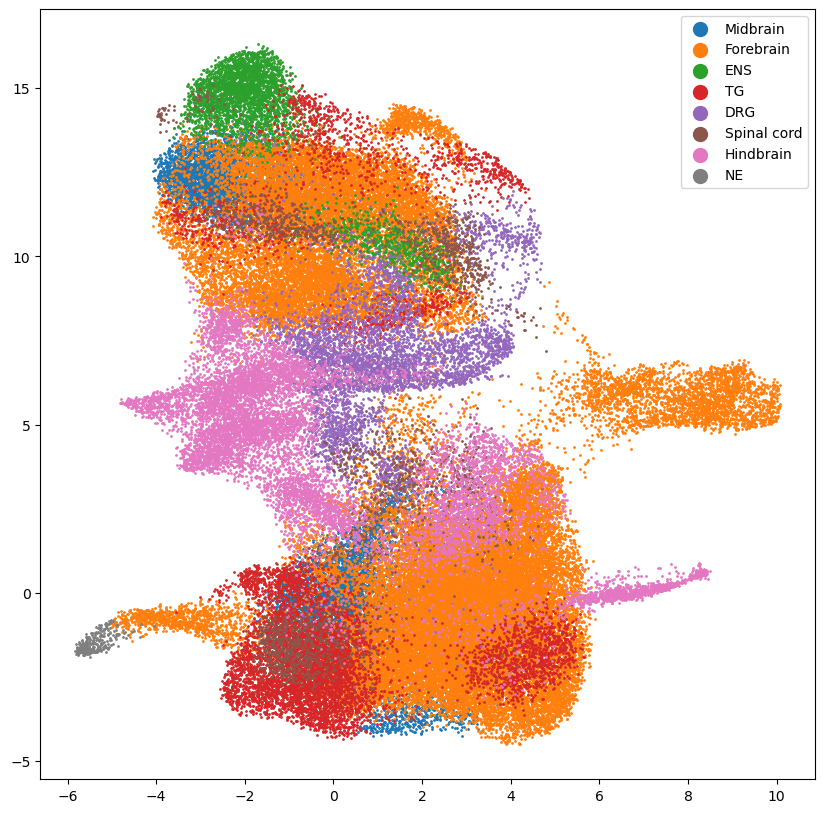

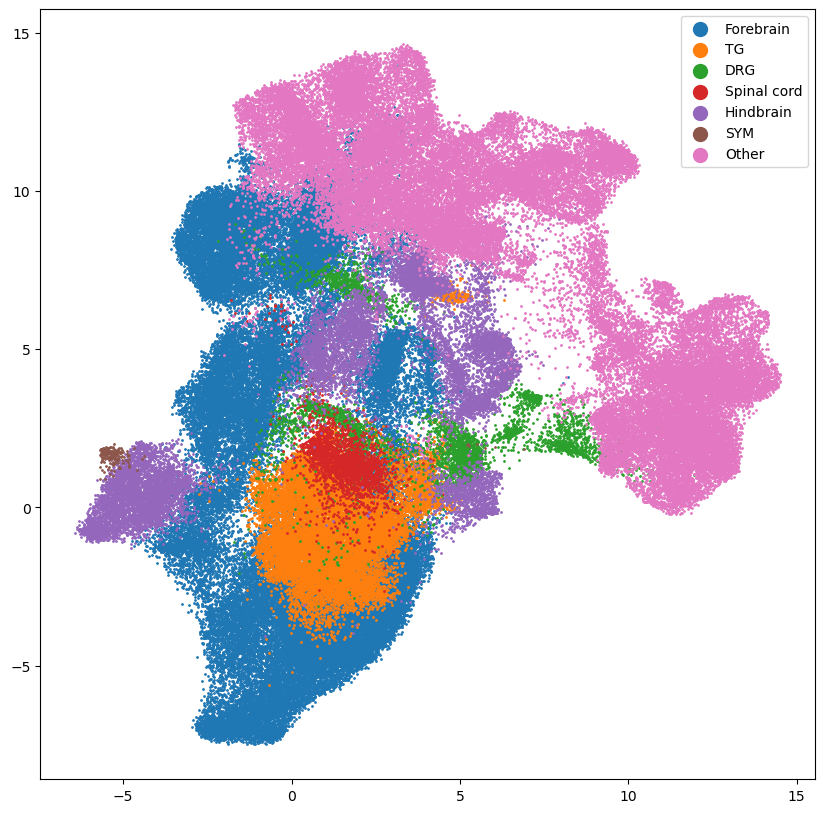

In [4]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

df = pd.read_csv("science.adn6121_table_s7.tsv",sep="\t",index_col=0)

for fh in files:
    meta = pd.read_csv(fh,sep="\t",index_col=0)
    name = fh
    if 'NGN2' in name:
        TF = 'iGlut'
    if 'ASCL1' in name:
        TF = 'iGABA'
    if 'post' in name:
        timing = 'post'
    if 'pre' in name:
        timing = 'pre'
    
    name = TF+"_"+timing
    meta['Region'] = list(df.loc[name+"_"+meta['final_clustering'].astype('str'),'Region'])
    meta['Neuron_type'] = list(df.loc[name+"_"+meta['final_clustering'].astype('str'),'Neuron_type'])
    meta['Division'] = list(df.loc[name+"_"+meta['final_clustering'].astype('str'),'Division'])
    meta.to_csv("reformat/"+fh,sep="\t")
    plt.figure(figsize=(10,10))
    for region in list(set(meta['Region'])):
        meta_region = meta.loc[meta['Region']==region]
        x,y = meta_region['umap_1'],meta_region['umap_2']
        plt.scatter(x,y,s=1,label=region)
    plt.legend(markerscale=10)
    plt.show()
    plt.close()